1. Loading The Data\
Dataset I’m going to use includes charges from patients. \
I highly recommend that you download this dataset and write your codes with me. \
You can access my codes from here. First, let’s import the dataset. \
I’m going to load the dataset using Pandas. Let me first import Pandas.\

In [1]:
import pandas as pd

Pandas is an excellent library for data loading and data preprocessing. 
Now, let me load the dataset with the read_csv method.

In [2]:
data = pd.read_csv("insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


2. Understanding The Dataset
Understanding the data is very important before building a machine learning model. 
For example, let’s see the number of rows and columns of the dataset. 
I’m going to use the shape attribute to do this.

In [3]:
data.shape
data.info()
data.isnull()
data.isnull().sum()

data.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

3. Data Preprocessing
Let’s convert object types to category types.

In [4]:
data['sex'] = data['sex'].astype('string')
data['region'] = data['region'].astype('string')
data['smoker'] = data['smoker'].astype('string')

# Convert any ints to floats to make signature inference more robust 
data['age'] = data['age'].astype(int)
data['children'] = data['children'].astype(int)


data.dtypes

age                  int64
sex         string[python]
bmi                float64
children             int64
smoker      string[python]
region      string[python]
charges            float64
dtype: object

Now, let’s go ahead and take a look at the statistics of numeric variables with the describe method. 
If we use the transpose of the dataset, you can see the statistics better.

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


Now, let’s look at the mean charges for smokers and non-smokers. 
To do this, let’s first group with the groupby method. 
I’m going to use the round method to see only two numbers after the comma.

In [6]:
smoke_data = data.groupby("smoker", observed=True).mean(numeric_only=True).round(2)
smoke_data

,age,bmi,children,charges
smoker,,,,
no,39.39,30.65,1.09,8434.27
yes,38.51,30.71,1.11,32050.23


In [7]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


4. Data Visualization
You can understand the dataset better with data visualization. 
Now, let’s look at the relationships of numeric variables using the seaborn. 
First, let me import seaborn.

In [8]:
import seaborn as sns

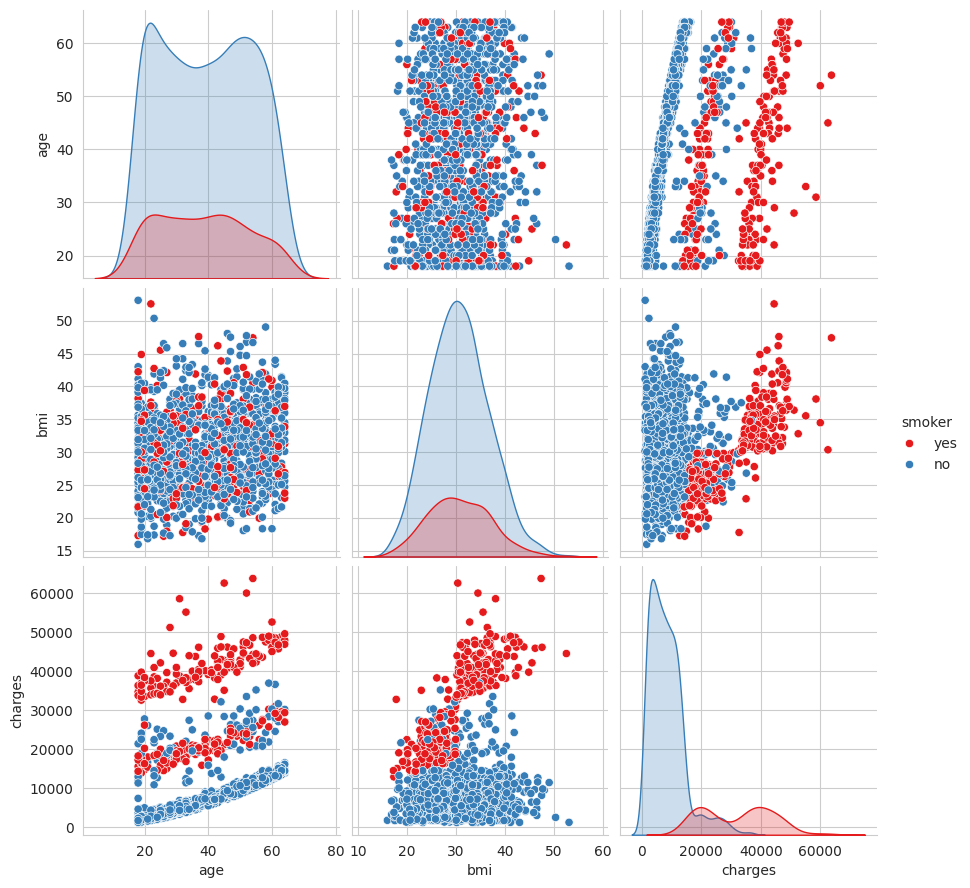

In [9]:
sns.set_style("whitegrid")

sns.pairplot(
    data[["age", "bmi", "charges", "smoker"]],
    hue = "smoker",
    height = 3,
    palette = "Set1")

For example, when the age variable increases, both smokers and non-smokers pay more. 
Now, let’s look at the correlation between the variables.

<Axes: >

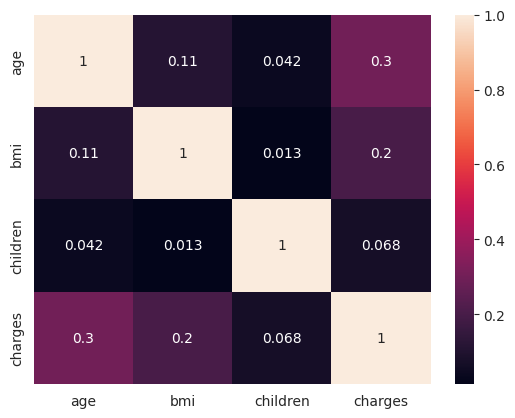

In [10]:
sns.heatmap(data[["age", "bmi", "children", "charges"]].corr(), annot=True)

Notice that there is a relationship between charges and the other variables.

Now lets setup the data as a collection of features and the associated labels.

In [11]:
features = data
features

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


These steps creat a dataset of labelled vlaues, as well as a table with those target variables removed.

In [12]:
labels = features["charges"]
labels.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [13]:
features = features.drop("charges", axis = 1)
features.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


Before the model is built, the dataset is split into training and testing. 
The model is built with the training data, and the model is evaluated with the test data. 
You can use the train_test_split method in scikit-learn to split the dataset into training and testing. 
With this method, you can easily split the dataset. First, let’s import this method.
Let’s split the dataset into 80 percent training and 20 percent testing.

In [14]:
from sklearn.model_selection import train_test_split

f_train,f_test,l_train,l_test=train_test_split(
    features,labels, 
    train_size = 0.80, 
    random_state = 1)

Now we create a pipeline\
It will encode the category columns\
It will then pass those encoded columns to the model


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor


oneHotEncoder = OneHotEncoder()
preprocess = ColumnTransformer(transformers=[('onehot', oneHotEncoder, ['sex','smoker','region'])],remainder='passthrough',force_int_remainder_cols=False)
model = DecisionTreeRegressor(max_depth=3, random_state=30)
pipeline = Pipeline([('preprocessor', preprocess),('model',model)])
pipeline.fit(f_train,l_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('onehot', OneHotEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', DecisionTreeRegressor(max_depth=3, random_state=30))])

6. Model Evaluation
Let’s take a look at the performance of the model. To do this, I’m going to use the coefficient of determination. 
The closer this value is to 1, the better the model. First, let’s take a look at the score of the model on the test data.

In [16]:
round(pipeline.score(f_test, l_test),3)

0.861

Now let’s take a look at another metric, mean squared error, to evaluate the model. 
For this, let’s first predict the test data with the predict method.

In [17]:
l_pred = pipeline.predict(f_test)
f_test.head()

,age,sex,bmi,children,smoker,region
559,19,male,35.53,0,no,northwest
1087,57,male,31.54,0,no,northwest
1020,51,male,37.00,0,no,southwest
460,49,female,36.63,3,no,southeast
802,21,male,22.30,1,no,southwest


In [18]:
l_pred

array([ 4042.6108272 , 13872.59761707, 10427.8173242 , 10427.8173242 ,
        4042.6108272 , 38230.01277825, 10427.8173242 , 13872.59761707,
        6599.94524684, 18540.37952293, 13872.59761707, 13872.59761707,
        6599.94524684,  6599.94524684,  4042.6108272 , 10427.8173242 ,
        6599.94524684,  6599.94524684, 13872.59761707, 13872.59761707,
       13872.59761707, 38230.01277825, 10427.8173242 , 10427.8173242 ,
        4042.6108272 ,  6599.94524684,  6599.94524684, 10427.8173242 ,
        6599.94524684,  6599.94524684, 13872.59761707,  6599.94524684,
       25245.71689333, 38230.01277825, 25245.71689333, 13872.59761707,
       38230.01277825, 18540.37952293, 13872.59761707, 45690.04626667,
        6599.94524684, 13872.59761707, 10427.8173242 , 13872.59761707,
        6599.94524684, 13872.59761707,  4042.6108272 , 38230.01277825,
       10427.8173242 , 13872.59761707, 13872.59761707, 13872.59761707,
        4042.6108272 , 10427.8173242 , 18540.37952293,  6599.94524684,
      

In [19]:
from sklearn.metrics import mean_squared_error
import math

Let’s take a look at the square root of the mean squares error.

In [20]:
math.sqrt(mean_squared_error(l_test, l_pred))

4558.7805332898015

7. Model Prediction
Now, I’m going to predict the first row as an example. First, let’s select the first row of the test data.

In [21]:
data_new = f_train[:1]
data_new

,age,sex,bmi,children,smoker,region
216,53,female,26.6,0,no,northwest


Let me predict the data with our model.

In [22]:
pipeline.predict(data_new)

array([13872.59761707])

Let’s take a look at the real value.

In [23]:
l_train[:1]

216    10355.641
Name: charges, dtype: float64

As you can see, our model predicted close to the real value.

MLFlow is used for MLOps.  It lets us run repeatable experiements, as well as saving the model and loading it.

In [24]:
import mlflow
import mlflow.sklearn
from mlflow.types.schema import Schema, ColSpec
from mlflow.models import ModelSignature, infer_signature
import onnx
from skl2onnx import convert_sklearn
from skl2onnx import to_onnx
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

import numpy as np
import uuid

As we will be rendering some large tables, lets remove the page wrapping

In [25]:
pd.set_option('display.width', 1000)

Define a helper meathod for calculating a series of interesting metrics from the actual and predicted values.
This can be used on single values or whole lists of values.

In [26]:
def eval_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    return rmse, mae, r2

Step1:  Define the experiment, this will provide a wrapper for the implementation of several runs.
For example each run, may adjust one or more input parameters.
mlflow.log_param() can be used to log input variables and output variables.

In [27]:
mlflow.set_experiment(f'Decision Tree Regression Onnx')

<Experiment: artifact_location='/home/cdsw/.experiments/7pnw-iauh-4mbi-k5h6', creation_time=None, experiment_id='7pnw-iauh-4mbi-k5h6', last_update_time=None, lifecycle_stage='active', name='Decision Tree Regression Onnx', tags={}>

Step2:  Runs help us to record seperate model training and prediction steps
You can loop within an experiement, generating mulitple runs.
When evaluating each run you can store the metrics with 
mlflow.log_metric()
These metrics can then be compared across runs.

In [31]:
input_schema = Schema([
    ColSpec("integer"),
    ColSpec("string"),
    ColSpec("float"),
    ColSpec("integer"),
    ColSpec("string"),
    ColSpec("string"),
    ColSpec("float"),    
])
output_schema = Schema([
    ColSpec("float"),
])
signature = ModelSignature(inputs=input_schema, outputs=output_schema)

In [32]:
max_depth_range = [3,4,5]
random_state_range = [32, 34, 42]

for max_depth, random_state in zip(max_depth_range, random_state_range):

    with mlflow.start_run():
        
        mlflow.log_param("max_depth", max_depth) 
        mlflow.log_param("random_state", random_state)

        oneHotEncoder = OneHotEncoder()
        preprocess = ColumnTransformer(transformers=[('onehot', oneHotEncoder, ['sex','smoker','region'])],remainder='passthrough',force_int_remainder_cols=False)
        model = DecisionTreeRegressor(max_depth=max_depth, random_state=random_state)
        pipeline = Pipeline([('preprocessor', preprocess),('model',model)])
        pipeline.fit(f_train,l_train)
        
        l_pred = pipeline.predict(f_test)
        l_pred.dtype

        #signature = signature = infer_signature(f_test[:1], l_pred)
  
        (rmse, mae, r2) = eval_metrics(l_test, l_pred)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("mae", mae)
        
        onnxdt = to_onnx(pipeline, f_test[:1])

        model_meta = mlflow.onnx.log_model(onnxdt, "onnx_dt101", registered_model_name="onnx_dt101", signature=signature, metadata={"type":"decision tree", "owner":"chris_royles", "type":"onnx"})
        print(model_meta)
        print(model_meta.artifact_path)
  
mlflow.end_run()


Creating run for experiment_id: 9sg2-lqbw-re7e-hcuz, user_id: cdsw, run_name: None
Successfully registered model 'onnx_dt101'.
experiment id 9sg2-lqbw-re7e-hcuz 
2026/09/18 16:52:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: onnx_dt101, version 37
Created version '37' of model 'onnx_dt101'.


onnx_dt101


Creating run for experiment_id: 9sg2-lqbw-re7e-hcuz, user_id: cdsw, run_name: None
Successfully registered model 'onnx_dt101'.
experiment id 9sg2-lqbw-re7e-hcuz 
2026/09/18 16:52:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: onnx_dt101, version 38
Created version '38' of model 'onnx_dt101'.


onnx_dt101


Creating run for experiment_id: 9sg2-lqbw-re7e-hcuz, user_id: cdsw, run_name: None
Successfully registered model 'onnx_dt101'.
experiment id 9sg2-lqbw-re7e-hcuz 
2026/09/18 16:52:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: onnx_dt101, version 39
Created version '39' of model 'onnx_dt101'.


onnx_dt101


Generate predictions from the model, and create the associated metrics.
Log the metrics and the model

In [33]:
import onnxruntime as rt
import mlflow.onnx
import mlflow.pyfunc

mlflow.set_experiment(f'Decision Tree Regression (Loaded)')
  
with mlflow.start_run():
  
  mlflow_model_onnx = mlflow.onnx.load_model('/home/cdsw/.experiments/7pnw-iauh-4mbi-k5h6/x5up-7pvg-op3f-khnq/artifacts/onnx_dt101')
  mlflow_model_pyfunc = mlflow.pyfunc.load_model('/home/cdsw/.experiments/7pnw-iauh-4mbi-k5h6/1qd9-34sw-1x6v-ddes/artifacts/onnx_dt101')

    
  prediction = mlflow_model_pyfunc.predict(f_test[:1]) 
  print(prediction)

Creating run for experiment_id: 9sg2-lqbw-re7e-hcuz, user_id: cdsw, run_name: None


MlflowException: Failed to enforce schema of data '     age   sex    bmi  children smoker     region
559   19  male  35.53         0     no  northwest' with schema '['age': long (required), 'sex': string (required), 'bmi': double (required), 'children': long (required), 'smoker': string (required), 'region': string (required)]'. Error: Incompatible input types for column sex. Can not safely convert string to <U0.

In [30]:
check = mlflow_model.predict([["age","sex","bmi","children","smoker","region"],["50.0","male","33.7","4","no","northwest"]])
check

NameError: name 'mlflow_model' is not defined

In [ ]:
  mlflow.log_param("input", f_test[:1])
  mlflow.log_param("prediction", prediction)
  mlflow.end_run()